<a href="https://colab.research.google.com/github/xiaann622/Analystlab/blob/week-8/health_extraction_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Health Performance: Life Expectancy Capstone
**Extracting and analyzing the Health theme from World Bank WDI data**

## Objective
To extract the Health theme from the full WDI dataset, then analyze how
life expectancy at birth has changed globally over time, in order to
answer:
- How has global life expectancy changed since 1990?
- Which countries have the highest and lowest life expectancy today?
- Which countries have improved the most (or declined) over the last
  decade?
- Is there evidence that lower-life-expectancy countries are catching up
  to higher-life-expectancy ones over time?

## Problem Statement
Public health outcomes vary enormously across the world, and policymakers,
health organizations, and researchers need clear, data-driven answers
about where health outcomes are improving, where they're stalling, and
which countries most need support. This notebook uses real World Bank data
across ~190 economies to answer that with evidence.

## Data Source
World Bank **World Development Indicators (WDI)**, theme: **Health**
(251 indicators), narrowed to the headline indicator **Life expectancy at
birth, total (years)** (`SP.DYN.LE00.IN`).
https://databank.worldbank.org/source/world-development-indicators


In [ ]:
!pip install country_converter --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.5 MB/s eta 0:00:00


In [ ]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import country_converter as coco

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11})

## Step 1 — Load your data

Upload the 3 files from your `WDI_CSV.zip` using the Colab file browser
(folder icon in the left sidebar → upload icon), or run the cell below to
use the upload picker. These are the SAME 3 files used for the Economy
extraction — no need to re-download anything if you already have them in
this Colab session:
- `WDICSV.csv` — the actual data (all themes, all indicators)
- `WDISeries.csv` — indicator metadata (has the `Topic` column)
- `WDICountry.csv` — country metadata (has the `Region` column)

In [ ]:
REQUIRED = ["WDICSV.csv", "WDISeries.csv", "WDICountry.csv"]
missing = [f for f in REQUIRED if not os.path.exists(f)]

if missing:
    try:
        from google.colab import files
        print(f"Missing: {missing} -- opening upload picker (select all 3 files at once)")
        files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"Missing {missing}. If you're not in Colab, place these files in the "
            f"working directory manually and re-run this cell."
        )
    missing = [f for f in REQUIRED if not os.path.exists(f)]

if missing:
    raise FileNotFoundError(f"Still missing after upload: {missing}. Re-run this cell.")
else:
    print("All 3 files present:", REQUIRED)

DATA_PATH = "WDICSV.csv"
SERIES_PATH = "WDISeries.csv"
COUNTRY_PATH = "WDICountry.csv"
!ls -la *.csv

All 3 files present: ['WDICSV.csv', 'WDISeries.csv', 'WDICountry.csv']
-rw-r--r-- 1 root root   156476 Aug 31 20:52 WDICountry.csv
-rw-r--r-- 1 root root 10485760 Aug 31 20:52 WDICSV.csv
-rw-r--r-- 1 root root  5961768 Aug 31 20:52 WDISeries.csv


## Step 2 — Extract: Filter to the Health theme

The official WDI Topic name for Health is simply **`Health`** (confirmed
against the real metadata file — matching with `startswith("Health")`
correctly excludes the separate `Gender: Health` sub-topic, which belongs
to the Gender theme, not Health). It covers 251 indicators spanning
mortality, disease prevention, nutrition, reproductive health, and health
systems.

In [ ]:
THEME = "Health"

series = pd.read_csv(SERIES_PATH)
health_series = series[series["Topic"].str.startswith(THEME, na=False)]
health_codes = set(health_series["Series Code"])
print(f"{len(health_codes)} indicators found under '{THEME}'")
print()
print("Sub-topics within Health:")
print(health_series["Topic"].value_counts())

data = pd.read_csv(DATA_PATH, on_bad_lines='skip', encoding='latin1')
print(f"\nFull dataset: {data.shape[0]} rows, {data['Indicator Code'].nunique()} indicators, "
      f"{data['Country Code'].nunique()} country/aggregate codes")

health_data = data[data["Indicator Code"].isin(health_codes)]
print(f"Health theme only: {health_data.shape[0]} rows, {health_data['Indicator Code'].nunique()} indicators")

# Save the full Health-theme slice (all 251 indicators) in case you want
# to explore other health indicators beyond life expectancy later
health_data.to_csv("WDI_health_only.csv", index=False)
print("Saved -> WDI_health_only.csv (all 251 Health indicators, wide format)")

251 indicators found under 'Health'

Sub-topics within Health:
Topic
Health: Population: Structure        58
Health: Mortality                    39
Health: Risk factors                 33
Health: Nutrition                    30
Health: Disease prevention           27
Health: Health systems               23
Health: Reproductive health          16
Health: Population: Dynamics         13
Health: Universal Health Coverage    10
Health                                2
Name: count, dtype: int64

Full dataset: 396970 rows, 1498 indicators, 265 country/aggregate codes
Health theme only: 66515 rows, 251 indicators
Saved -> WDI_health_only.csv (all 251 Health indicators, wide format)


## Step 3 — Narrow to one indicator for the deep-dive analysis

251 health indicators is too many to analyze meaningfully in one pass.
This notebook focuses on **Life expectancy at birth, total (years)** as
the headline measure of health outcomes — the health-theme analog to GDP
per capita for economic performance. (Swap `INDICATOR_CODE` below to
analyze a different health indicator instead — browse
`health_series[['Series Code','Indicator Name']]` for other options, e.g.
`SH.DYN.MORT` for under-5 mortality rate, or `SH.XPD.CHEX.GD.ZS` for health
expenditure as % of GDP.)

In [ ]:
INDICATOR_CODE = "SP.DYN.LE00.IN"  # Life expectancy at birth, total (years)

raw = health_data[health_data["Indicator Code"] == INDICATOR_CODE].copy()
print(f"Selected indicator: {raw['Indicator Name'].iloc[0]}")
print(f"Rows (one per economy/aggregate): {raw.shape[0]}")

Selected indicator: Life expectancy at birth, total (years)
Rows (one per economy/aggregate): 265


## Step 4 — Clean

Same three real issues as the Economy extraction, checked fresh for this
indicator rather than assumed to be identical:

1. **Footer rows** — drop rows with no `Country Code`.
2. **Aggregate rows disguised as countries** — 47 World Bank
   regional/income-group aggregates excluded using `WDICountry.csv`'s
   `Region` field (blank for aggregates, filled in for real economies).
3. **Missing values** — life expectancy data tends to be more complete
   than GDP-per-capita-PPP historically (fewer surveys required), so we
   check the actual missing-value rate for this indicator rather than
   assuming it matches the Economy analysis.

In [ ]:
if 'ï»¿Country Name' in raw.columns:
    raw = raw.rename(columns={'ï»¿Country Name': 'Country Name'})

raw = raw[raw["Country Code"].notna()].copy()

country_meta = pd.read_csv(COUNTRY_PATH)
real_economy_codes = set(country_meta[country_meta["Region"].notna()]["Country Code"])
aggregate_rows_found = raw[~raw["Country Code"].isin(real_economy_codes)]
if len(aggregate_rows_found):
    print(f"Excluding {len(aggregate_rows_found)} aggregate rows (not real economies): "
          f"{aggregate_rows_found['Country Name'].tolist()}")
raw = raw[raw["Country Code"].isin(real_economy_codes)]

year_cols = [c for c in raw.columns if c[:2] in ("19", "20")]
long_df = raw.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="life_expectancy_years",
)
long_df["year"] = long_df["year"].astype(int)
long_df = long_df.rename(columns={"Country Name": "country", "Country Code": "country_code"})

long_df["life_expectancy_years"] = pd.to_numeric(long_df["life_expectancy_years"], errors="coerce")

missing = long_df["life_expectancy_years"].isna().sum()
print(f"Missing values: {missing} of {len(long_df)} ({missing/len(long_df)*100:.1f}%) corriente")

decade = (long_df["year"] // 10) * 10
print(long_df.assign(decade=decade).groupby("decade")["life_expectancy_years"]
      .apply(lambda s: f"{s.isna().mean()*100:.0f}% missing"))

long_df = long_df.dropna(subset=["life_expectancy_years"])
long_df = long_df[long_df["life_expectancy_years"] > 0]  # sanity check
long_df = long_df.drop_duplicates(subset=["country_code", "year"])

print(f"\nClean dataset: {long_df.shape[0]} country-year rows, {long_df['country_code'].nunique()} economies")

Excluding 48 aggregate rows (not real economies): ['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World', 'Caribbean small states', 'Central Europe and the Baltics', 'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (excluding high income)', 'East Asia & Pacific (IDA & IBRD countries)', 'Euro area', 'Europe & Central Asia', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia (IDA & IBRD countries)', 'European Union', 'Heavily indebted poor countries (HIPC)', 'High income', 'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only', 'IDA total', 'Late-demographic dividend', 'Latin America & Caribbean', 'Latin America & Caribbean (excluding high income)', 'Latin America & the Caribbean (IDA & IBRD countries)', 'Least developed countries: UN classification', 'Low & middle income', 'Low income', 'Lower middle income', 'Middle East, North Africa, Afghanistan & Pakistan', 'Middle East, North Africa, Afghanistan & Pakistan (excludi

## Step 5 — Enrich: continent classification + calculated columns

Note: life expectancy changes are conventionally reported in **years
gained/lost**, not percentage growth (a country going from 50 to 55 years
is "+5 years", not "+10%" — both are mathematically valid, but years is
the standard way this is discussed in public health).

In [ ]:
cc = coco.CountryConverter()
codes = long_df["country_code"].unique().tolist()
mapping = cc.convert(names=codes, src="ISO3", to="continent", not_found=None)
lookup = dict(zip(codes, mapping))
long_df["continent"] = long_df["country_code"].map(lookup).fillna("Other/Territory")

long_df = long_df.sort_values(["country_code", "year"]).reset_index(drop=True)
long_df["yoy_change_years"] = long_df.groupby("country_code")["life_expectancy_years"].diff().round(2)

pivot = long_df.pivot(index="country_code", columns="year", values="life_expectancy_years")
latest_year, base_year = pivot.columns.max(), pivot.columns.max() - 10
ten_yr_change = pivot[latest_year] - pivot[base_year]
long_df["change_last_10yr_years"] = long_df["country_code"].map(ten_yr_change).round(2)

latest = long_df[long_df["year"] == latest_year].copy()
latest["rank_latest_year"] = latest["life_expectancy_years"].rank(ascending=False, method="min").astype(int)
long_df = long_df.merge(latest[["country_code", "rank_latest_year"]], on="country_code", how="left")

print(f"Added continent, yoy_change_years, change_last_10yr_years ({base_year}-{latest_year}), rank_latest_year")
long_df.head()

Added continent, yoy_change_years, change_last_10yr_years (2014-2024), rank_latest_year


,country,country_code,year,life_expectancy_years,continent,yoy_change_years,change_last_10yr_years,rank_latest_year_x,rank_latest_year_y
0,Aruba,ABW,1960,64.049,America,NaN,1.24,92,92
1,Aruba,ABW,1961,64.215,America,0.17,1.24,92,92
2,Aruba,ABW,1962,64.602,America,0.39,1.24,92,92
3,Aruba,ABW,1963,64.944,America,0.34,1.24,92,92
4,Aruba,ABW,1964,65.303,America,0.36,1.24,92,92


## Step 6 — Save the cleaned dataset

In [ ]:
long_df.to_csv("wdi_life_expectancy_clean.csv", index=False)
print(f"Saved -> wdi_life_expectancy_clean.csv ({long_df.shape[0]} rows)")

Saved -> wdi_life_expectancy_clean.csv (14071 rows)


## Step 7 — Analyze: KPIs

In [ ]:
latest_year = int(long_df["year"].max())
latest = long_df[long_df["year"] == latest_year]

world_avg = latest["life_expectancy_years"].mean()
highest = latest.loc[latest["life_expectancy_years"].idxmax()]
lowest = latest.loc[latest["life_expectancy_years"].idxmin()]
most_improved = latest.loc[latest["change_last_10yr_years"].idxmax()]
most_declined = latest.loc[latest["change_last_10yr_years"].idxmin()]

base = long_df[long_df["year"] == latest_year - 10][["country_code", "life_expectancy_years"]].rename(columns={"life_expectancy_years": "base_life_exp"})
merged = base.merge(latest[["country_code", "change_last_10yr_years"]], on="country_code").dropna()
convergence_corr = round(merged["base_life_exp"].corr(merged["change_last_10yr_years"]), 3)

kpi = {
    "latest_year": latest_year,
    "countries_covered": int(latest["country_code"].nunique()),
    "world_avg_life_expectancy": round(world_avg, 1),
    "highest_country": highest["country"], "highest_value": round(highest["life_expectancy_years"], 1),
    "lowest_country": lowest["country"], "lowest_value": round(lowest["life_expectancy_years"], 1),
    "most_improved_country": most_improved["country"], "most_improved_years": round(most_improved["change_last_10yr_years"], 1),
    "most_declined_country": most_declined["country"], "most_declined_years": round(most_declined["change_last_10yr_years"], 1),
    "convergence_correlation": convergence_corr,
}
print(json.dumps(kpi, indent=2))
with open("kpi_summary_health.json", "w") as f:
    json.dump(kpi, f, indent=2)

{
  "latest_year": 2024,
  "countries_covered": 217,
  "world_avg_life_expectancy": 74.0,
  "highest_country": "Monaco",
  "highest_value": 86.5,
  "lowest_country": "Nigeria",
  "lowest_value": 54.6,
  "most_improved_country": "Central African Republic",
  "most_improved_years": 17.4,
  "most_declined_country": "West Bank and Gaza",
  "most_declined_years": -3.6,
  "convergence_correlation": -0.695
}


## Step 8 — Visualize

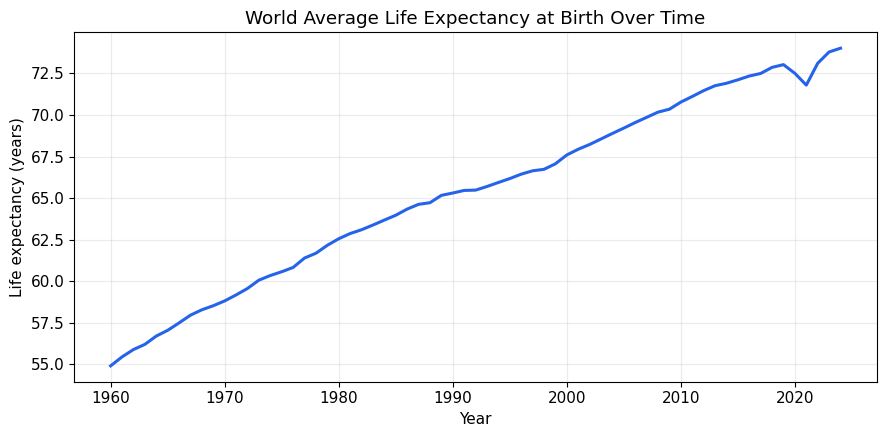

In [ ]:
trend = long_df.groupby("year")["life_expectancy_years"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(trend.index, trend.values, color="#2563eb", linewidth=2.2)
ax.set_title("World Average Life Expectancy at Birth Over Time")
ax.set_xlabel("Year"); ax.set_ylabel("Life expectancy (years)")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("chart_world_trend_health.png", dpi=150); plt.show()

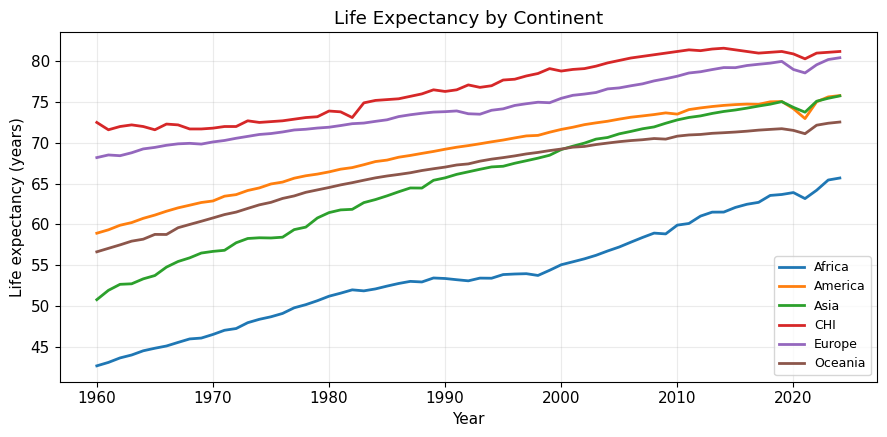

In [ ]:
cont_trend = long_df.groupby(["year", "continent"])["life_expectancy_years"].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 4.5))
for continent in cont_trend.columns:
    ax.plot(cont_trend.index, cont_trend[continent], linewidth=2, label=continent)
ax.set_title("Life Expectancy by Continent")
ax.set_xlabel("Year"); ax.set_ylabel("Life expectancy (years)")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("chart_continent_trend_health.png", dpi=150); plt.show()

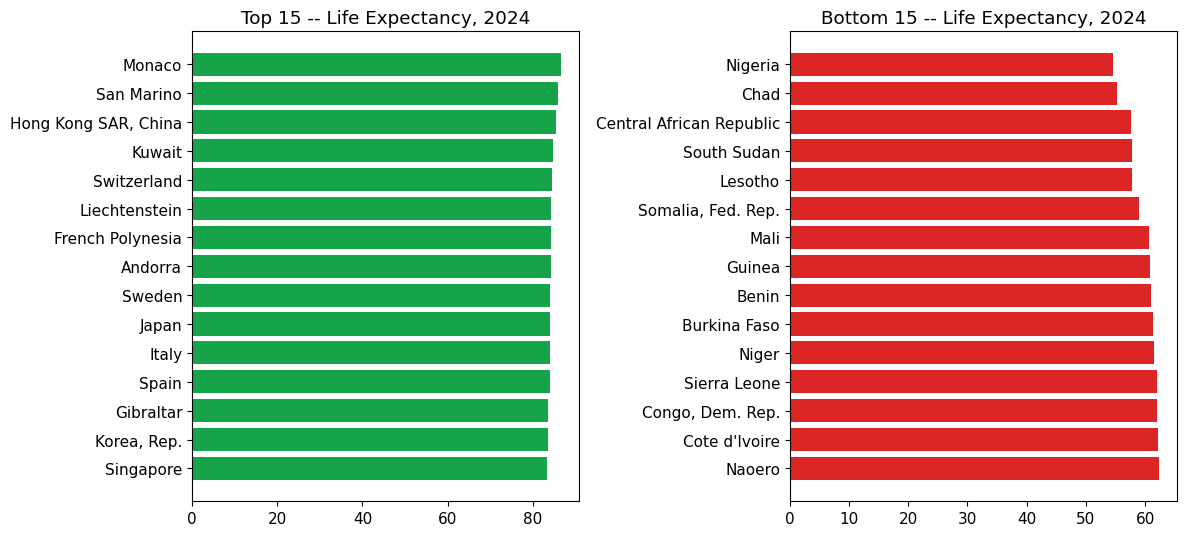

In [ ]:
top15 = latest.sort_values("life_expectancy_years", ascending=False).head(15)
bottom15 = latest.sort_values("life_expectancy_years", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].barh(top15["country"][::-1], top15["life_expectancy_years"][::-1], color="#16a34a")
axes[0].set_title(f"Top 15 -- Life Expectancy, {latest_year}")
axes[1].barh(bottom15["country"][::-1], bottom15["life_expectancy_years"][::-1], color="#dc2626")
axes[1].set_title(f"Bottom 15 -- Life Expectancy, {latest_year}")
plt.tight_layout(); plt.savefig("chart_top_bottom_health.png", dpi=150); plt.show()

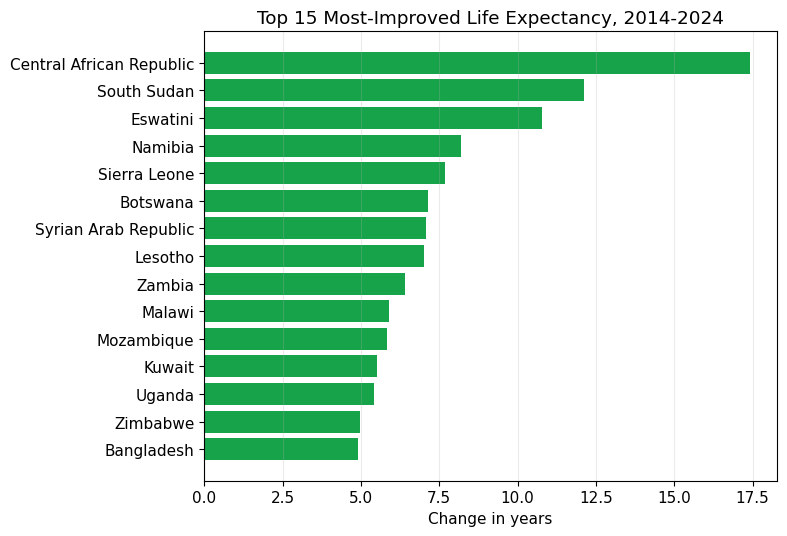

In [ ]:
most_improved15 = latest.sort_values("change_last_10yr_years", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#16a34a" if v >= 0 else "#dc2626" for v in most_improved15["change_last_10yr_years"][::-1]]
ax.barh(most_improved15["country"][::-1], most_improved15["change_last_10yr_years"][::-1], color=colors)
ax.set_title(f"Top 15 Most-Improved Life Expectancy, {latest_year-10}-{latest_year}")
ax.set_xlabel("Change in years")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout(); plt.savefig("chart_most_improved_health.png", dpi=150); plt.show()

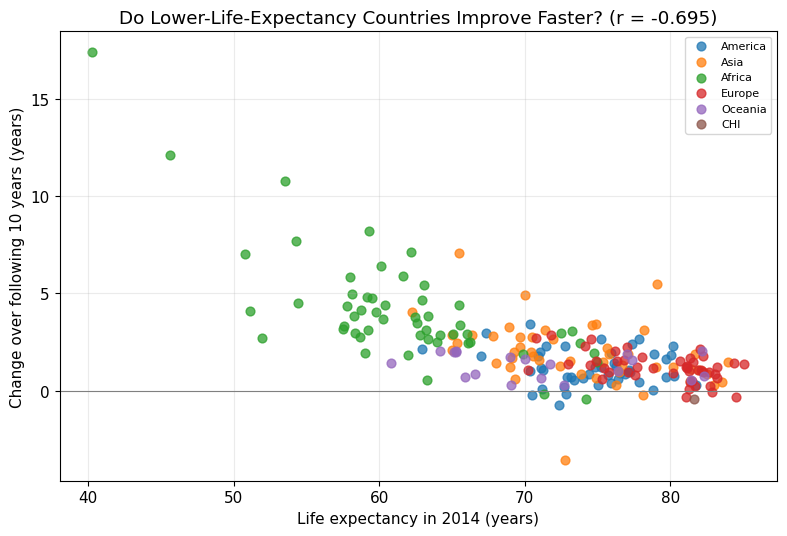

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_data = merged.merge(latest[["country_code", "continent"]], on="country_code")
for cont in plot_data["continent"].unique():
    subset = plot_data[plot_data["continent"] == cont]
    ax.scatter(subset["base_life_exp"], subset["change_last_10yr_years"], label=cont, alpha=0.75, s=40)
ax.set_xlabel(f"Life expectancy in {latest_year-10} (years)")
ax.set_ylabel("Change over following 10 years (years)")
ax.set_title(f"Do Lower-Life-Expectancy Countries Improve Faster? (r = {convergence_corr})")
ax.axhline(0, color="grey", linewidth=0.8)
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("chart_convergence_health.png", dpi=150); plt.show()

## Key Findings

Fill this in with your own printed KPI values from Step 7 before your demo.

- **World average life expectancy:** use `kpi['world_avg_life_expectancy']`
- **Highest:** `kpi['highest_country']` at `kpi['highest_value']` years
- **Lowest:** `kpi['lowest_country']` at `kpi['lowest_value']` years
- **Most improved (10yr):** `kpi['most_improved_country']`, +`kpi['most_improved_years']` years
- **Most declined (10yr):** `kpi['most_declined_country']`, `kpi['most_declined_years']` years
- **Convergence correlation:** `kpi['convergence_correlation']`
